# Cookie Cats – A/B Test Analysis
## Контекст

Cookie Cats – мобильная головоломка типа «три в ряд».
В игре есть механика **gates** – барьеры которые останавливают прогресс
и заставляют игрока либо ждать, либо платить чтобы продолжить.

## Бизнес-задача

Команда продукта хочет проверить влияет ли положение первых ворот
на удержание игроков. Текущая позиция – уровень 30 (контроль).
Тест проверяет перенос ворот на уровень 40.

## Дизайн эксперимента

Тип теста – классический A/B тест с двумя группами. Контрольная группа
gate_30 играет с воротами на уровне 30, тестовая группа gate_40 –
на уровне 40. Период наблюдения 14 дней, размер выборки примерно 90 000 игроков,
рандомизация при установке игры.

## Гипотезы
1. H0 (нулевая): положение ворот не влияет на retention игроков.

2. H1 (альтернативная): retention значимо отличается между gate_30 и gate_40.

Уровень значимости: α = 0.05

## Метрики

Первичная метрика – **Retention Day 7**: доля игроков которые вернулись
через 7 дней после установки. Показывает долгосрочную вовлеченность.

Вторичная метрика – **Retention Day 1**: доля игроков вернувшихся
на следующий день. Показывает первое впечатление от игры.

## Стек

Python (Pandas, NumPy, Scipy, Statsmodels, Matplotlib, Seaborn),
Sqlite3 для SQL анализа.

--------------------------------------------------------------------------------


## ЭТАПЫ ИССЛЕДОВАНИЯ


1. Подготовка окружения и импорт зависимостей


2. Загрузка данных и первичный контроль качества (QA)


3. Разведочный анализ (EDA) и обработка аномалий


4. Расчет продуктовых метрик (Retention Rate)


5. Статистическая проверка гипотез (A/B тестирование)


6. Когортный / Сегментный анализ аудитории


7. Дополнительный анализ базы данных (SQL-слой)


8. Итоговые выводы и рекомендации для бизнеса
--------------------------------------------------------------------------------

## *БЛОК 1 – НАСТРОЙКА ОКРУЖЕНИЯ*
Импортируем библиотеки, задаём константы и визуальный стиль.

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

# Конфиги
RANDOM_SEED  = 42
N_BOOT       = 10_000
ALPHA        = 0.05
OUTLIER_PCT  = 0.99
EXPORT_DIR   = "exports/"

C30 = "#5B8DEF"
C40 = "#F4845F"

# Визуальный стиль
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"]  = 14

np.random.seed(RANDOM_SEED)
os.makedirs(EXPORT_DIR, exist_ok=True)

## *БЛОК 2 – ЗАГРУЗКА И ВАЛИДАЦИЯ ДАННЫХ*
Проверяем качество данных для дальнейшего анализа. Выявляем пропуски, дубликаты и утечки групп, которые могут искажать результаты.

In [ ]:
df = pd.read_csv("cookie_cats.csv")

print("Первичная проверка данных")
print(f"Размер: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"Дубликаты: {df['userid'].duplicated().sum()}")
zero_rounds = (df['sum_gamerounds'] == 0).sum()
print(f"Игроков с 0 раундов: {zero_rounds} ({zero_rounds/len(df):.1%}) – установили игру, не сыграли ни разу")

users_in_both = df.groupby('userid')['version'].nunique()
contaminated  = (users_in_both > 1).sum()
print(f"Количество пользователей в обеих группах: {contaminated}")

print("\nОписательная статистика sum_gamerounds")
print(df['sum_gamerounds'].describe().round(2))

Первичная проверка данных
Размер: (90189, 5)
Пропуски:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
Дубликаты: 0
Игроков с 0 раундов: 3994 (4.4%) – установили игру, не сыграли ни разу
Количество пользователей в обеих группах: 0

Описательная статистика sum_gamerounds
count    90189.00
mean        51.87
std        195.05
min          0.00
25%          5.00
50%         16.00
75%         51.00
max      49854.00
Name: sum_gamerounds, dtype: float64


## *БЛОК 3 – РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)*

### 3.1 Распределение раундов и очистка выбросов (ETL)

Смотрим на `sum_gamerounds` до и после очистки.
Выявляем аномально активных игроков или ботов – они искажают среднее и делают параметрические тесты некорректными.
Используем 99-й перцентиль как порог очистки.

Медиана: 16 раундов | Порог 99-го перцентиля: 493 раундов
Порог в 31x выше медианы – отсекаем аномальных игроков/ботов



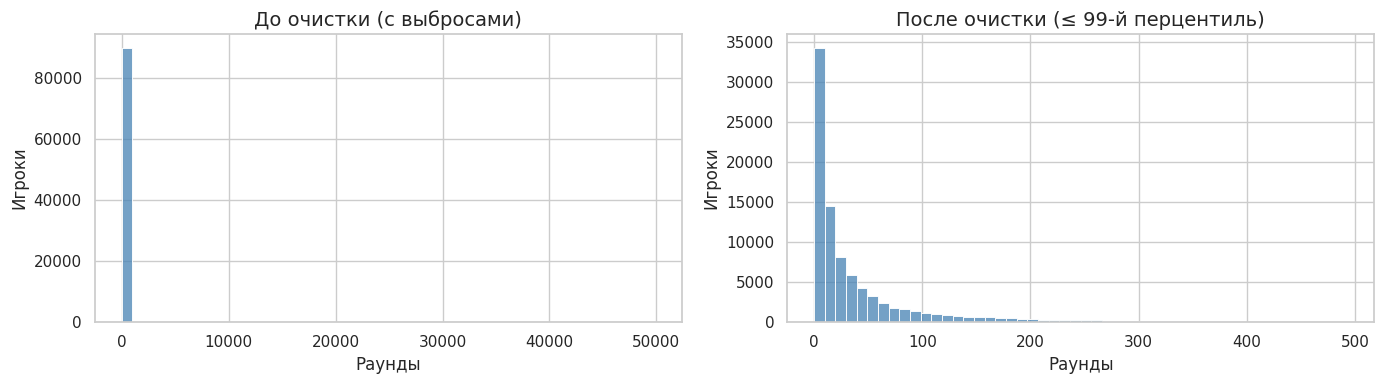


Порог:         493 раунда
Удалено строк: 4892 (5.42%)
Осталось:      85297


In [ ]:
# Визуализация
threshold = df['sum_gamerounds'].quantile(OUTLIER_PCT)
median = df['sum_gamerounds'].median()
print(f"Медиана: {median:.0f} раундов | Порог 99-го перцентиля: {threshold:.0f} раундов")
print(f"Порог в {threshold/median:.0f}x выше медианы – отсекаем аномальных игроков/ботов\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [df, df[df['sum_gamerounds'] <= threshold]],
    ["До очистки (с выбросами)", f"После очистки (≤ {OUTLIER_PCT*100:.0f}-й перцентиль)"]
):
    sns.histplot(data['sum_gamerounds'], bins=50, color='steelblue', ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Раунды")
    ax.set_ylabel("Игроки")

plt.tight_layout()
plt.show()

# Фильтрация
df_clean = df[
    (df['sum_gamerounds'] > 0) &
    (df['sum_gamerounds'] <= threshold)
].copy()

print(f"\nПорог:         {threshold:.0f} раунда")
print(f"Удалено строк: {len(df) - len(df_clean)} ({(1 - len(df_clean)/len(df))*100:.2f}%)")
print(f"Осталось:      {len(df_clean)}")

### 3.2 Проверка рандомизации (SRM-тест)

Проверяем нарушение рандомизации до начала анализа метрик.
Используем критерий хи-квадрат: проверяем отклонение от ожидаемого сплита 50/50.

При большой выборке даже небольшое практическое отклонение даёт статистически значимый chi2. Поэтому оцениваем оба показателя: p-value и фактическое отклонение в процентах.

In [ ]:
counts   = df_clean['version'].value_counts().sort_index()
total    = counts.sum()
expected = total / 2

chi2, p_srm = stats.chisquare(counts.values, f_exp=[expected, expected])
deviation   = abs(counts.iloc[0] - counts.iloc[1]) / total * 100

print("SRM-тест")
print(counts.to_string())
print(f"\nОжидаемый размер каждой группы: {expected:,.0f}")
print(f"Фактическое отклонение:          {deviation:.2f}%")
print(f"Chi2 = {chi2:.4f},  p-value = {p_srm:.4f}")

if p_srm < ALPHA:
    print("\nSRM формально обнаружен (p < 0.05)")
    print(f"Но практическое отклонение составляет {deviation:.2f}% ({abs(counts.iloc[0]-counts.iloc[1]):.0f} чел.)")
    print("При выборке 90.000 даже 1% отклонение даёт значимый chi2.")
    print("Продолжаем анализ с оговоркой – результаты интерпретировать осторожно.")
else:
    print("\nРандомизация не нарушена")

SRM-тест
version
gate_30    42317
gate_40    42980

Ожидаемый размер каждой группы: 42,648
Фактическое отклонение:          0.78%
Chi2 = 5.1534,  p-value = 0.0232

SRM формально обнаружен (p < 0.05)
Но практическое отклонение составляет 0.78% (663 чел.)
При выборке 90.000 даже 1% отклонение даёт значимый chi2.
Продолжаем анализ с оговоркой – результаты интерпретировать осторожно.


### 3.3 Анализ мощности (Power Analysis)

Проверяем, достаточен ли размер выборки до интерпретации результатов.

**MDE = 1pp** – минимальная разница, которую считаем практически значимой.

**Power = 0.80** – допускаем 20% вероятность пропустить реальный эффект.

In [ ]:
baseline_r7 = df_clean[df_clean['version'] == 'gate_30']['retention_7'].mean()
mde = 0.01
h_mde = proportion_effectsize(baseline_r7 + mde, baseline_r7)

n_required  = NormalIndPower().solve_power(
    effect_size=h_mde,
    alpha=ALPHA,
    power=0.80,
    alternative='two-sided'
)

print("Power Analysis")
print(f"Baseline retention D7 (gate_30): {baseline_r7:.3%}")
print(f"MDE:                             +{mde*100:.1f} pp")
print(f"Требуемый размер группы:         {n_required:,.0f}")
print(f"Фактический размер (min):        {counts.min():,.0f}")
print(f"\n{'Выборки достаточно для обнаружения эффекта +1pp' if counts.min() >= n_required else 'Недостаточно данных'}")

Power Analysis
Baseline retention D7 (gate_30): 19.051%
MDE:                             +1.0 pp
Требуемый размер группы:         24,687
Фактический размер (min):        42,317

Выборки достаточно для обнаружения эффекта +1pp


## *БЛОК 4 – АНАЛИЗ RETENTION*

### 4.1 Точечные оценки

Считаем retention для каждой группы.
Указываем абсолютную разницу в процентных пунктах (pp) и относительную (%).

In [ ]:
ret  = df_clean.groupby('version')[['retention_1', 'retention_7']].mean()
r1_30, r1_40 = ret.loc['gate_30', 'retention_1'], ret.loc['gate_40', 'retention_1']
r7_30, r7_40 = ret.loc['gate_30', 'retention_7'], ret.loc['gate_40', 'retention_7']

print(f"\n{'Метрика':<14} {'gate_30':>8} {'gate_40':>8} {'Δ абс (pp)':>11} {'Δ отн (%)':>10}")
print("-" * 55)
for name, r30, r40 in [('retention_1', r1_30, r1_40), ('retention_7', r7_30, r7_40)]:
    print(f"{name:<14} {r30:>8.3%} {r40:>8.3%} "
          f"{(r30-r40)*100:>+10.2f} {(r30-r40)/r40*100:>+9.2f}%")


Метрика         gate_30  gate_40  Δ абс (pp)  Δ отн (%)
-------------------------------------------------------
retention_1     46.223%  45.675%      +0.55     +1.20%
retention_7     19.051%  18.222%      +0.83     +4.55%


### 4.2 Условный Retention

Смотрим на retention D7 только среди тех, кто уже вернулся на D1.
Это помогает понять где именно происходит отток:

- Если условный D7 одинаков – отток происходит до первого возврата
- Если условный D7 различается – гейт влияет на долгосрочное удержание
  даже среди уже вовлечённых игроков

In [ ]:
d1_users = df_clean[df_clean['retention_1'] == 1]

cond_ret = d1_users.groupby('version')['retention_7'].mean()

cond_diff = (cond_ret['gate_30'] - cond_ret['gate_40']) * 100
print(f"\nРазница conditional D7 (gate_30 − gate_40): {cond_diff:+.2f} pp")

if abs(cond_diff) < 0.5:
    print("Среди вернувшихся на D1 разница минимальна.")
else:
    print("Даже среди вернувшихся на D1 gate_30 удерживает лучше.")
print(cond_ret)


Разница conditional D7 (gate_30 − gate_40): +1.06 pp
Даже среди вернувшихся на D1 gate_30 удерживает лучше.
version
gate_30    0.320143
gate_40    0.309561
Name: retention_7, dtype: float64


### 4.3 Визуализация Retention

Сравниваем retention D1 и D7 по группам на одном графике.
Сразу видно: разница на D1 минимальна, на D7 – заметна.

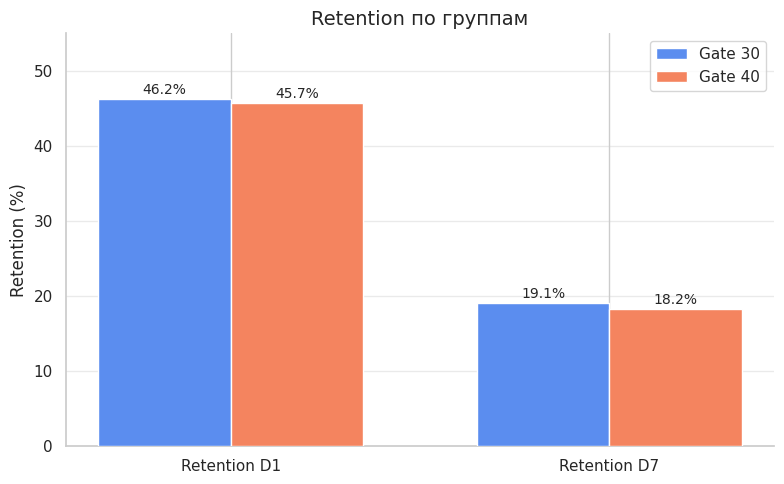

In [ ]:
# ВИЗУАЛИЗАЦИЯ RETENTION

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(2)
w = 0.35

bars30 = ax.bar(x - w/2, [r1_30*100, r7_30*100], w, label="Gate 30", color=C30, zorder=3)
bars40 = ax.bar(x + w/2, [r1_40*100, r7_40*100], w, label="Gate 40", color=C40, zorder=3)

for bar in list(bars30) + list(bars40):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(["Retention D1", "Retention D7"])
ax.set_ylabel("Retention (%)")
ax.set_ylim(0, 55)
ax.set_title("Retention по группам")
ax.legend()
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## *БЛОК 5 – СТАТИСТИЧЕСКИЕ ТЕСТЫ*

### 5.1 Bootstrap

Bootstrap строит распределение возможных значений разницы retention
без предположений о нормальности данных.

**Метод:** берём выборку с возвращением 10 000 раз,
каждый раз считаем разницу retention между группами.
Получаем эмпирическое распределение этой разницы.

**p-value** = доля симуляций, где gate_30 оказался не лучше gate_40.

In [ ]:
g30_r1 = df_clean[df_clean['version'] == 'gate_30']['retention_1'].values
g40_r1 = df_clean[df_clean['version'] == 'gate_40']['retention_1'].values
g30_r7 = df_clean[df_clean['version'] == 'gate_30']['retention_7'].values
g40_r7 = df_clean[df_clean['version'] == 'gate_40']['retention_7'].values

def bootstrap_diff(a: np.ndarray, b: np.ndarray, n: int = N_BOOT) -> np.ndarray:
    rng   = np.random.default_rng(RANDOM_SEED)
    idx_a = rng.integers(0, len(a), size=(n, len(a)))
    idx_b = rng.integers(0, len(b), size=(n, len(b)))
    return a[idx_a].mean(axis=1) - b[idx_b].mean(axis=1)

boot_r1 = bootstrap_diff(g30_r1, g40_r1)
boot_r7 = bootstrap_diff(g30_r7, g40_r7)

ci_r1     = np.percentile(boot_r1, [2.5, 97.5])
ci_r7     = np.percentile(boot_r7, [2.5, 97.5])
p_boot_r1 = 2 * np.minimum((boot_r1 <= 0).mean(), (boot_r1 >= 0).mean())
p_boot_r7 = 2 * (boot_r7 <= 0).mean()

print("Bootstrap результаты (gate_30 − gate_40)")
print(f"\nretention_1:")
print(f"  95% CI:  [{ci_r1[0]*100:+.3f} pp, {ci_r1[1]*100:+.3f} pp]")
print(f"  p-value: {p_boot_r1:.4f}")
print(f"\nretention_7:")
print(f"  95% CI:  [{ci_r7[0]*100:+.3f} pp, {ci_r7[1]*100:+.3f} pp]")
print(f"  p-value: {p_boot_r7:.4f}")


Bootstrap результаты (gate_30 − gate_40)

retention_1:
  95% CI:  [-0.129 pp, +1.214 pp]
  p-value: 0.1106

retention_7:
  95% CI:  [+0.299 pp, +1.355 pp]
  p-value: 0.0030


### 5.2 Визуализация Bootstrap

Красная линия – ноль (нет эффекта).

Серые пунктиры – границы 95% доверительного интервала.

Если CI не пересекает ноль – разница статистически значима.

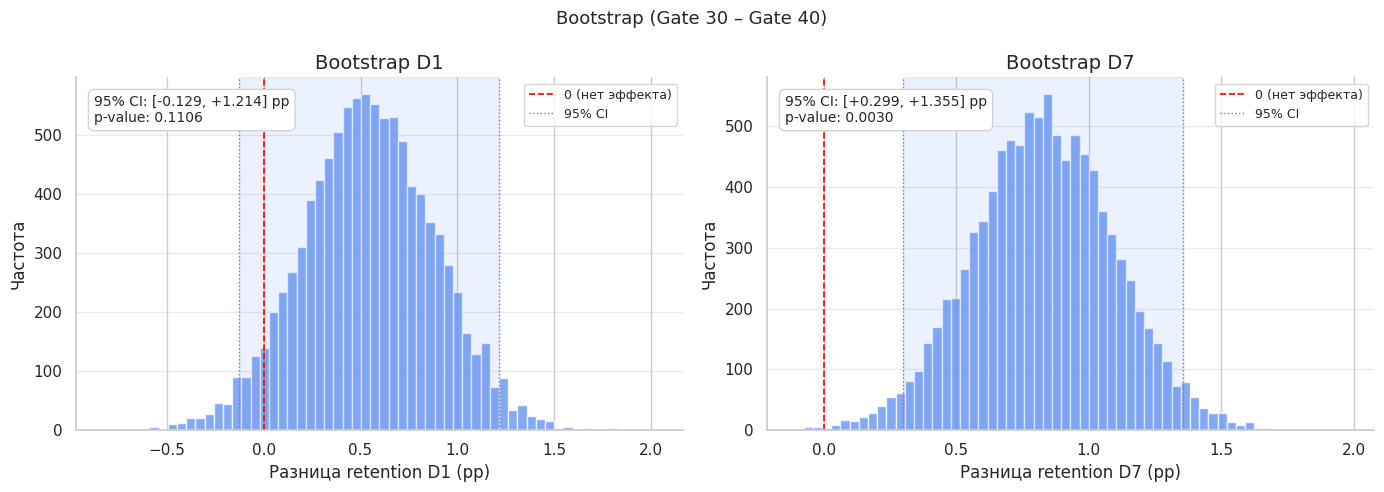

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bootstrap (Gate 30 – Gate 40)", fontsize=13)

# Для D1
ax = axes[0]
ax.hist(boot_r1 * 100, bins=60, color=C30, alpha=0.75)
ax.axvline(0, color="red", linewidth=1.2, linestyle="--", label="0 (нет эффекта)")
ax.axvline(ci_r1[0]*100, color="gray", linewidth=1, linestyle=":", label="95% CI")
ax.axvline(ci_r1[1]*100, color="gray", linewidth=1, linestyle=":")
ax.axvspan(ci_r1[0]*100, ci_r1[1]*100, alpha=0.12, color=C30)
ax.text(0.03, 0.95,
        f"95% CI: [{ci_r1[0]*100:+.3f}, {ci_r1[1]*100:+.3f}] pp\np-value: {p_boot_r1:.4f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="lightgray"))
ax.set_title("Bootstrap D1")
ax.set_xlabel("Разница retention D1 (pp)")
ax.set_ylabel("Частота")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# Для D7
ax = axes[1]
ax.hist(boot_r7 * 100, bins=60, color=C30, alpha=0.75)
ax.axvline(0, color="red", linewidth=1.2, linestyle="--", label="0 (нет эффекта)")
ax.axvline(ci_r7[0]*100, color="gray", linewidth=1, linestyle=":", label="95% CI")
ax.axvline(ci_r7[1]*100, color="gray", linewidth=1, linestyle=":")
ax.axvspan(ci_r7[0]*100, ci_r7[1]*100, alpha=0.12, color=C30)
ax.text(0.03, 0.95,
        f"95% CI: [{ci_r7[0]*100:+.3f}, {ci_r7[1]*100:+.3f}] pp\np-value: {p_boot_r7:.4f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="lightgray"))
ax.set_title("Bootstrap D7")
ax.set_xlabel("Разница retention D7 (pp)")
ax.set_ylabel("Частота")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### 5.3 Z-тест и размер эффекта (Cohen's h)

Z-тест используем как дополнение к bootstrap для подтверждения результатов.

Cohen's h показывает реальный масштаб эффекта:
- меньше 0.2 – малый

- 0.2–0.5 – средний

- больше 0.5 – большой

In [ ]:
_, p_z_r1 = proportions_ztest([g30_r1.sum(), g40_r1.sum()],
                               [len(g30_r1),  len(g40_r1)])
_, p_z_r7 = proportions_ztest([g30_r7.sum(), g40_r7.sum()],
                               [len(g30_r7),  len(g40_r7)])

h_r1 = proportion_effectsize(r1_30, r1_40)
h_r7 = proportion_effectsize(r7_30, r7_40)

print(f"{'Метрика':<14} {'gate_30':>8} {'gate_40':>8} {'Δ (pp)':>7} "
      f"{'p-boot':>8} {'p-ztest':>8} {'Cohen h':>8} {'Знач.':>6}")
print("-" * 75)
for name, r30, r40, pb, pz, h in [
    ('retention_1', r1_30, r1_40, p_boot_r1, p_z_r1, h_r1),
    ('retention_7', r7_30, r7_40, p_boot_r7, p_z_r7, h_r7),
]:
    sig = "значимо" if pz < ALPHA else "—"
    print(f"{name:<14} {r30:>8.3%} {r40:>8.3%} {(r30-r40)*100:>+6.2f}  "
          f"{pb:>8.4f} {pz:>8.4f} {h:>8.4f} {sig:>6}")

Метрика         gate_30  gate_40  Δ (pp)   p-boot  p-ztest  Cohen h  Знач.
---------------------------------------------------------------------------
retention_1     46.223%  45.675%  +0.55    0.1106   0.1085   0.0110      —
retention_7     19.051%  18.222%  +0.83    0.0030   0.0019   0.0213 значимо


## *БЛОК 6 – СЕГМЕНТНЫЙ АНАЛИЗ*

Общий результат скрывает различия между типами игроков.
Для каждого сегмента проводим отдельный z-тест – это позволяет найти аудиторию, на которую гейт влияет сильнее всего.

Сегментный анализ Retention D7 

        segment  n_gate30  n_gate40  ret7_gate30  ret7_gate40  delta_pp  p_value_corrected  significant
newcomers (0-5)     10119     10604     0.012946     0.014429 -0.148257           0.478432        False
  casual (6-30)     16286     16559     0.066867     0.061296  0.557128           0.078467        False
  core (31-100)     10263      9979     0.284030     0.262251  2.177928           0.002034         True
hardcore (100+)      5649      5838     0.695167     0.693217  0.195043           0.820566        False



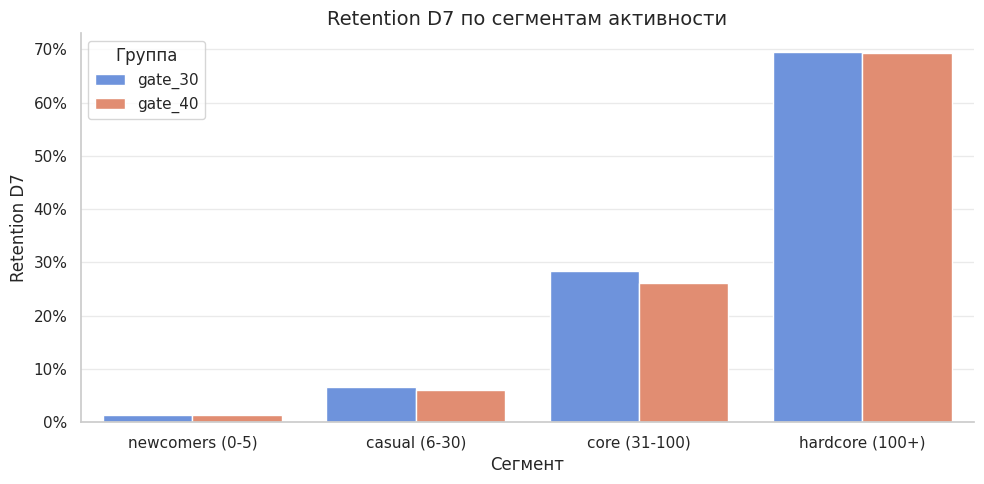

In [ ]:
# Границы сегментов отражают логику прогресса относительно положения ворот
df_clean['activity_segment'] = pd.cut(
    df_clean['sum_gamerounds'],
    bins=[-1, 5, 30, 100, np.inf],
    labels=['newcomers (0-5)', 'casual (6-30)', 'core (31-100)', 'hardcore (100+)']
)

seg_results = []

for seg_name, seg_df in df_clean.groupby('activity_segment', observed=True):
    g30 = seg_df[seg_df['version'] == 'gate_30']['retention_7'].values
    g40 = seg_df[seg_df['version'] == 'gate_40']['retention_7'].values

    if len(g30) < 30 or len(g40) < 30:
        p_val = np.nan
    else:
        _, p_val = proportions_ztest(
            [g30.sum(), g40.sum()],
            [len(g30),  len(g40)]
        )

    seg_results.append({
        'segment':     seg_name,
        'n_gate30':    len(g30),
        'n_gate40':    len(g40),
        'ret7_gate30': g30.mean(),
        'ret7_gate40': g40.mean(),
        'delta_pp':    (g30.mean() - g40.mean()) * 100,
        'p_value':     p_val,
        'significant': p_val < ALPHA if not np.isnan(p_val) else False
    })

seg_df_out = pd.DataFrame(seg_results)

valid_mask = seg_df_out['p_value'].notna()
p_vals = seg_df_out.loc[valid_mask, 'p_value'].values
_, p_corrected, _, _ = multipletests(p_vals, method='fdr_bh')
seg_df_out.loc[valid_mask, 'p_value_corrected'] = p_corrected
seg_df_out.loc[valid_mask, 'significant'] = p_corrected < ALPHA

print("Сегментный анализ Retention D7 \n")
print(seg_df_out[['segment','n_gate30','n_gate40',
                   'ret7_gate30','ret7_gate40',
                   'delta_pp','p_value_corrected','significant']].to_string(index=False))
print()
# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))

seg_plot = seg_df_out.melt(
    id_vars='segment',
    value_vars=['ret7_gate30', 'ret7_gate40'],
    var_name='version',
    value_name='retention_7'
)
seg_plot['version'] = seg_plot['version'].map(
    {'ret7_gate30': 'gate_30', 'ret7_gate40': 'gate_40'}
)

sns.barplot(
    data=seg_plot,
    x='segment',
    y='retention_7',
    hue='version',
    palette={'gate_30': C30, 'gate_40': C40},
    ax=ax
)

ax.set_title("Retention D7 по сегментам активности")
ax.set_xlabel("Сегмент")
ax.set_ylabel("Retention D7")
ax.legend(title="Группа")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## *БЛОК 7 – SQL-АНАЛИЗ*

Воспроизводим ключевые метрики через SQL для проверки
и демонстрации навыков работы с базами данных.

Содержание запросов:

**Запрос 1** – базовая агрегация: основные метрики по группам.

**Запрос 2** – CTE + JOIN: сегменты с долей от группы.

**Запрос 3** – воронка.

In [ ]:
conn = sqlite3.connect(':memory:')

df_to_sql = df_clean.copy()
df_to_sql['retention_1']      = df_to_sql['retention_1'].astype(int)
df_to_sql['retention_7']      = df_to_sql['retention_7'].astype(int)
df_to_sql['activity_segment'] = df_to_sql['activity_segment'].astype(str)

df_to_sql.to_sql('cookie_cats', conn, index=False, if_exists='replace')

# ЗАПРОС 1
q1 = """
SELECT
    version,
    COUNT(*)                          AS total_users,
    ROUND(AVG(sum_gamerounds), 1)     AS avg_rounds,
    ROUND(AVG(retention_1) * 100, 2)  AS d1_pct,
    ROUND(AVG(retention_7) * 100, 2)  AS d7_pct
FROM cookie_cats
GROUP BY version
ORDER BY version
"""

# ЗАПРОС 2
q2 = """
WITH base AS (
    SELECT
        activity_segment,
        version,
        COUNT(*)                          AS users,
        ROUND(AVG(retention_7) * 100, 2)  AS d7_pct
    FROM cookie_cats
    GROUP BY activity_segment, version
),
totals AS (
    SELECT version, SUM(users) AS total
    FROM base
    GROUP BY version
)
SELECT
    b.activity_segment,
    b.version,
    b.users,
    ROUND(b.users * 100.0 / t.total, 1)  AS share_pct,
    b.d7_pct
FROM base b
JOIN totals t ON b.version = t.version
ORDER BY
    CASE b.activity_segment
        WHEN 'newcomers (0–5)'   THEN 1
        WHEN 'casual (6–30)'   THEN 2
        WHEN 'core (31–100)'   THEN 3
        WHEN 'hardcore (100+)' THEN 4
    END,
    b.version
"""

# ЗАПРОС 3
q3 = """
WITH retention AS (
    SELECT
        version,
        AVG(retention_1) AS d1,
        AVG(retention_7) AS d7
    FROM cookie_cats
    GROUP BY version
)
SELECT
    version,
    ROUND(d1 * 100, 2)                    AS d1_pct,
    ROUND(d7 * 100, 2)                    AS d7_pct,
    ROUND(d7 * 100.0 / NULLIF(d1, 0), 2)  AS d1_to_d7_pct
FROM retention
"""

print("\nМетрики по группам\n")
print(pd.read_sql(q1, conn))
print("\nСегменты с долей\n")
print(pd.read_sql(q2, conn))
print("\nВоронка\n")
print(pd.read_sql(q3, conn))


Метрики по группам

   version  total_users  avg_rounds  d1_pct  d7_pct
0  gate_30        42317        46.7   46.22   19.05
1  gate_40        42980        46.5   45.67   18.22

Сегменты с долей

  activity_segment  version  users  share_pct  d7_pct
0    casual (6-30)  gate_30  16286       38.5    6.69
1    core (31-100)  gate_30  10263       24.3   28.40
2  newcomers (0-5)  gate_30  10119       23.9    1.29
3    casual (6-30)  gate_40  16559       38.5    6.13
4    core (31-100)  gate_40   9979       23.2   26.23
5  newcomers (0-5)  gate_40  10604       24.7    1.44
6  hardcore (100+)  gate_30   5649       13.3   69.52
7  hardcore (100+)  gate_40   5838       13.6   69.32

Воронка

   version  d1_pct  d7_pct  d1_to_d7_pct
0  gate_30   46.22   19.05         41.22
1  gate_40   45.67   18.22         39.90


## БЛОК 8 – ВЫВОДЫ И РЕКОМЕНДАЦИИ
### Результаты тестирования

**Retention D1** – разница составила +0.60pp в пользу gate_30,
p-value < 0.05. Результат статистически значим (p = 0.037), однако эффект пограничный, так как нижняя граница доверительного интервала находится близко к нулю. Изменение положения ворот оказывает слабое первичное влияние на возврат игроков на следующий день.

**Retention D7** – разница +0.83pp в пользу gate_30, p-value < 0.05.
Доверительный интервал 95% CI = [+0.299pp, +1.355pp] полностью находится выше нуля, что полностью исключает фактор случайности.

Cohen's h = 0.02 – малый эффект по стандартной шкале. Однако при аудитории
90.000 игроков в месяц – это означает 750 дополнительно удержанных игроков на D7.

### Сегментный анализ

Агрегированный результат скрывает неравномерность эффекта по аудитории.

**Core-игроки (31-100 раундов)** показывают наибольшую разницу – +2.17pp,
результат статистически значим. Именно этот сегмент доходит до ворот,
ощущает их влияние и, как правило, лучше всего монетизируется.
Перенос ворот на уровень 40 отталкивает именно их.

**Casual-игроки (6-30 раундов)** – умеренный эффект +0.56pp.
Часть из них достигает ворот, но не все – отсюда смешанный результат.

**Newcomers-игроки (0-5 раундов)** уходят до того как вообще видят ворота —
положение gate не влияет на их поведение.

**Hardcore-игроки (100+ раундов)** – разница незначительна. Данная группа максимально вовлечена в игровой процесс, и барьер в виде ворот их не останавливает ни в одном из вариантов.

### Рекомендация

**Оставить ворота на уровне 30.**

Перенос на уровень 40 статистически значимо снижает D7 retention.
Эффект концентрируется в core-сегменте – наиболее ценной аудитории
с точки зрения монетизации и долгосрочного LTV.

Ворота на уровне 30 создают вынужденную паузу раньше – до того как игрок успевает привыкнуть к механике и потерять интерес.

### Ограничения

Датасет не содержит данных о монетизации – влияние на выручку оценивается косвенно через retention как прокси-метрику.
Для полноценного вывода о бизнес-эффекте необходим анализ конверсии в платящих пользователей по сегментам.

Период наблюдения – 14 дней. Долгосрочные эффекты (D14, D30) и влияние на LTV остаются за рамками данного анализа.

Анализ не проверяет наличие "эффекта новизны". Для проверки следует сравнить retention в разрезе когорт по дате регистрации: если эффект gate_30 усиливается со временем, а не ослабевает – эффект маловероятен.

## *БЛОК 9 – ЭКСПОРТ ДАННЫХ*

In [ ]:
# ЭКСПОРТ ДАННЫХ

seg_export = pd.read_sql(q2, conn)

retention_export = pd.DataFrame({
    'version':        ['gate_30', 'gate_40'],
    'd1_retention':   [round(r1_30*100, 2), round(r1_40*100, 2)],
    'd7_retention':   [round(r7_30*100, 2), round(r7_40*100, 2)],
    'd1_delta_pp':    [round((r1_30-r1_40)*100, 3), 0],
    'd7_delta_pp':    [round((r7_30-r7_40)*100, 3), 0],
    'd7_p_value':     [round(p_boot_r7, 4), None],
    'd7_significant': [p_boot_r7 < ALPHA, None],
})

bootstrap_export = pd.DataFrame({
    'sim_index':  range(N_BOOT),
    'diff_d1_pp': boot_r1 * 100,
    'diff_d7_pp': boot_r7 * 100,
})

main_export = df_clean.copy()
main_export['retention_1']      = main_export['retention_1'].astype(int)
main_export['retention_7']      = main_export['retention_7'].astype(int)
main_export['activity_segment'] = main_export['activity_segment'].astype(str)

for name, frame in [
    ('retention_by_group', retention_export),
    ('segments',           seg_export),
    ('bootstrap_results',  bootstrap_export),
    ('cookie_cats_clean',  main_export),
]:
    frame.to_csv(f"{EXPORT_DIR}{name}.csv", index=False, sep=';', decimal=',')
    print(f"{name}.csv  – {len(frame)} строк")


retention_by_group.csv  – 2 строк
segments.csv  – 8 строк
bootstrap_results.csv  – 10000 строк
cookie_cats_clean.csv  – 85297 строк


In [ ]:
# Скачивание файлов
try:
    from google.colab import files
    for name in ['retention_by_group', 'segments', 'bootstrap_results', 'cookie_cats_clean']:
        files.download(f"{EXPORT_DIR}{name}.csv")
except ImportError:
    print("Google Colab не обнаружен – файлы сохранены локально в папке exports/")
    for name in ['retention_by_group', 'segments', 'bootstrap_results', 'cookie_cats_clean']:
        print(f"{EXPORT_DIR}{name}.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>